# 📖 Understanding Recurrent Neural Network (RNN)

---

## 🔹 What is an RNN?
A **Recurrent Neural Network (RNN)** is a type of neural network designed to work with **sequential data** such as text, time series, or speech.  
It introduces the concept of **memory**, allowing the network to use information from previous steps to influence the current step.

Key idea:  
- RNNs have loops that allow information to persist across time steps.  
- This makes them suitable for data where the order of inputs matters.

---

## 🔹 Key Components of ANN
An **Artificial Neural Network (ANN)** is the foundation of deep learning. It is made up of layers of neurons connected together.

| Component        | Description                                                      |
|------------------|------------------------------------------------------------------|
| **Input Layer**  | Receives raw features from the dataset.                         |
| **Hidden Layers**| Layers where computations happen through weighted connections.   |
| **Activation Functions** | Introduce non-linearity (e.g., ReLU, Sigmoid).          |
| **Output Layer** | Produces final predictions (classification/regression).          |
| **Weights & Biases** | Parameters the network learns during training.               |

---

## 🔹 How ANN Works (Step by Step)
1. **Input Feeding:** Data is passed into the input layer as feature vectors.  
2. **Weighted Sum:** Each neuron calculates a weighted sum of its inputs plus a bias.  
3. **Activation Function:** The weighted sum passes through an activation function to introduce non-linearity.  
4. **Forward Propagation:** Outputs are sent to the next layer until the output layer is reached.  
5. **Loss Calculation:** The difference between predicted and actual output is measured using a loss function.  
6. **Backpropagation:** Gradients of the loss are computed w.r.t. weights and biases.  
7. **Weight Update:** Optimizer updates weights and biases to minimize the loss.  
8. **Iteration:** Steps 2–7 repeat over multiple epochs until the network learns.

---

## 🔹 Difference Between ANN and RNN

| Feature                    | ANN                              | RNN                                  |
|----------------------------|------------------------------------|--------------------------------------|
| **Data Type**              | Fixed-size inputs (tabular data) | Sequential data (text, time series) |
| **Memory**                 | No memory of previous inputs     | Remembers past inputs using hidden states |
| **Architecture**           | Feedforward only                 | Contains loops for temporal memory  |
| **Order Sensitivity**      | Ignores input order              | Sensitive to the order of inputs    |
| **Use Cases**              | Image classification, tabular data | Text processing, language modeling, speech recognition |

---

## 🔹 Why Use RNN?
✅ To model **sequential and temporal dependencies** in data.  
✅ RNNs can remember context from earlier inputs, making them ideal for:
- Natural Language Processing (NLP)
- Time Series Forecasting
- Speech Recognition
- Video Frame Analysis

Example: In a sentence, "The terrorist planted a ___," RNN considers previous words to predict "bomb" as the next word.

---

### ✅ Summary
- **ANN:** Good for fixed-size, non-sequential data.  
- **RNN:** Powerful for sequence data because of its ability to "remember" information over time.


# 🧠 RNN for Text Classification using Embeddings

In this notebook, we will:
- Create a **dummy dataset** (Terrorism vs Non-Terrorism)
- Preprocess text data using **Text Tokenization and Padding**
- Train a **simple RNN** to classify text
- Evaluate the model and display predictions

---

## 📌 1. Introduction

Text classification is a common task in Natural Language Processing (NLP). We can use **Recurrent Neural Networks (RNNs)** to learn patterns from text data.

Here we will use:
- **Text Tokenization and Padding and Embeddings** to convert text into numeric vectors
- A simple ANN built with TensorFlow/Keras

The goal is to classify texts as:
- `Terrorism`
- `Non-Terrorism`

---

## 📝 2. Dataset Preparation
We create a small dummy dataset with 50 text samples, labeled as `"Terrorism"` or `"Non-Terrorism"`.


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 1️⃣ Create Dummy Dataset
data = {
    "Text": [
        "Bomb blast in the city kills dozens",
        "Terrorist group claims responsibility for the attack",
        "Police found explosives in the abandoned car",
        "Peace talks between countries resume this week",
        "Charity raises funds for flood victims",
        "Military operation against militants continues",
        "Sports event gathers thousands of fans",
        "Government condemns the terror attack strongly",
        "New airport inaugurated in the capital",
        "Gunmen attack security forces in border area",
        "Students celebrate independence day with parade",
        "Suicide bomber detonates in crowded market",
        "Anti-terrorism unit arrests three suspects",
        "Healthcare workers vaccinated rural population",
        "Explosion near embassy kills five civilians",
        "Film festival showcases award-winning movies",
        "Airstrike targets terrorist hideouts in mountains",
        "Local community plants trees in public park",
        "Militant leader captured by special forces",
        "Economic growth hits record high this quarter",
        "Hostage situation ends with police intervention",
        "Education reforms announced by ministry",
        "Terror cell dismantled by intelligence agencies",
        "Cyclone warning issued for coastal regions",
        "Attackers open fire at security checkpoint",
        "Blood donation camp organized by students",
        "Rocket fired at military base from unknown location",
        "New hospital opens for rural health services",
        "Explosion damages government building downtown",
        "Football team wins national championship",
        "IED blast injures two soldiers on patrol",
        "Festival attracts international tourists",
        "Security forces raid terrorist safe house",
        "Heavy rainfall causes flooding in villages",
        "Bomb defused by bomb disposal squad",
        "Technology fair showcases innovation",
        "Terror suspects caught at international airport",
        "Volunteers clean up city streets after event",
        "Grenade attack reported in urban market",
        "Cultural exchange program launched",
        "Insurgents attack convoy near border",
        "Farmers protest against new agricultural laws",
        "Ambush on army convoy results in casualties",
        "Children participate in art competition",
        "Gunfire heard in remote tribal area",
        "Job fair provides employment opportunities",
        "Improvised explosive device found on roadside",
        "Health officials combat dengue outbreak",
        "Security alert issued after intelligence reports",
        "Peace conference aims to end conflict"
    ],
    "Label": [
        "Terrorism", "Terrorism", "Terrorism", "Non-Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism",
        "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism",
        "Non-Terrorism", "Terrorism", "Non-Terrorism", "Terrorism", "Non-Terrorism"
    ]
}

df = pd.DataFrame(data)
pd.set_option('display.max_colwidth', None)
print("📄 Full Dataset:")
# Display first 5 rows
print(df.shape)  # Should be (50, 2)
df

📄 Full Dataset:
(50, 2)


,Text,Label
0,Bomb blast in the city kills dozens,Terrorism
1,Terrorist group claims responsibility for the attack,Terrorism
2,Police found explosives in the abandoned car,Terrorism
3,Peace talks between countries resume this week,Non-Terrorism
4,Charity raises funds for flood victims,Non-Terrorism
5,Military operation against militants continues,Terrorism
6,Sports event gathers thousands of fans,Non-Terrorism
7,Government condemns the terror attack strongly,Terrorism
8,New airport inaugurated in the capital,Non-Terrorism
9,Gunmen attack security forces in border area,Terrorism


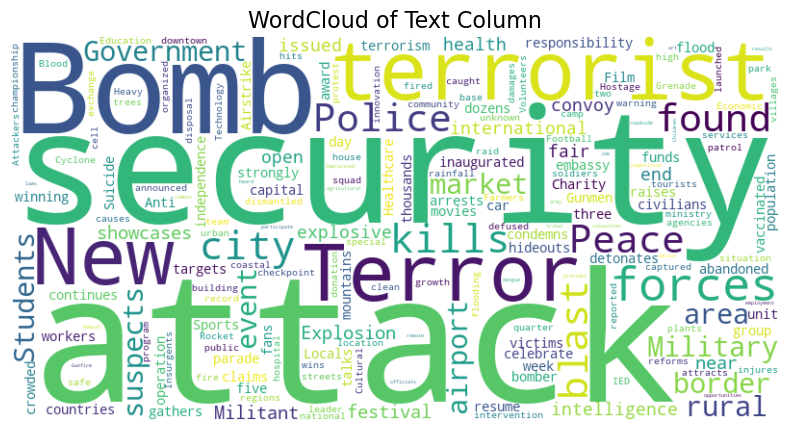

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text from the 'Text' column
text_data = ' '.join(df['Text'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # No axes
plt.title("WordCloud of Text Column", fontsize=16)
plt.show()

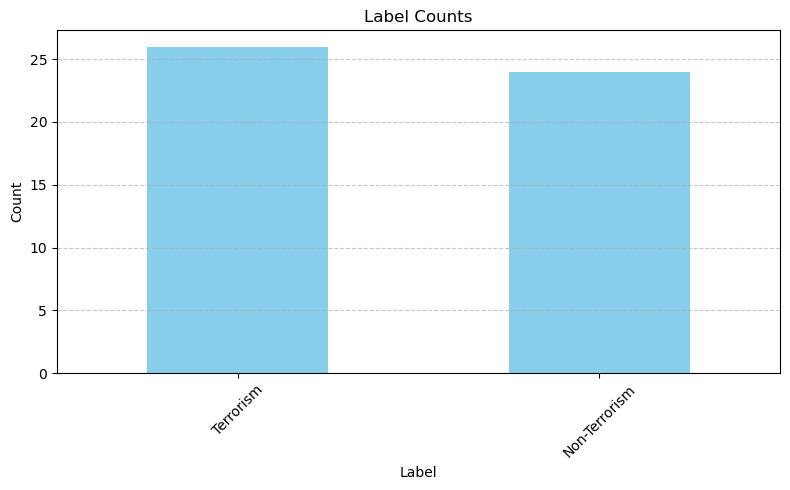

In [5]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = df['Label'].value_counts()

# Plot the bar graph
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Label Counts')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


---

## 📌 3. Preprocessing

### 🔤 3.1 Encode Labels
We use **LabelEncoder** to convert categorical labels (`Terrorism`, `Non-Terrorism`) into numeric (1, 0).


In [7]:
# Encode Labels
encoder = LabelEncoder()
df["Encoded_Label"] = encoder.fit_transform(df["Label"])
print("\n🔤 Encoded Labels (Terrorism=1, Non-Terrorism=0):")
df


🔤 Encoded Labels (Terrorism=1, Non-Terrorism=0):


,Text,Label,Encoded_Label
0,Bomb blast in the city kills dozens,Terrorism,1
1,Terrorist group claims responsibility for the attack,Terrorism,1
2,Police found explosives in the abandoned car,Terrorism,1
3,Peace talks between countries resume this week,Non-Terrorism,0
4,Charity raises funds for flood victims,Non-Terrorism,0
5,Military operation against militants continues,Terrorism,1
6,Sports event gathers thousands of fans,Non-Terrorism,0
7,Government condemns the terror attack strongly,Terrorism,1
8,New airport inaugurated in the capital,Non-Terrorism,0
9,Gunmen attack security forces in border area,Terrorism,1


### 📦 3.2 Convert Text to Numeric Vectors / Text Tokenization and Padding – Explanation

This section prepares raw text data for the Neural Network by converting it into numerical form.

---

### 🔹 Tokenizer
We use Keras’ `Tokenizer` to convert words into unique integer indices.

#### 📝 Key Points:
- **num_words=None**  
  Limits the tokenizer to the top most frequent words in the dataset.  
  Words outside this vocabulary are treated as out-of-vocabulary (OOV).

- **oov_token="<OOV>"**  
  Replaces any word not in the top 5000 with the special token `<OOV>`.

- **fit_on_texts(df["Text"])**  
  Builds the word index (vocabulary) from the dataset’s “Text” column.  
  Example:  
  - “attack” → 1  
  - “dangerous” → 2  
  - “city” → 3  

---

### 🔹 Convert Text to Sequences
The `texts_to_sequences` method replaces each word in the text with its corresponding integer index from the tokenizer vocabulary.  

Example:  
- Original text: `"the attack was dangerous"`  
- Sequence: `[5, 1, 8, 2]`

---

### 🔹 Pad Sequences
Neural Networks require inputs of the same length. Since sentences vary in length, we use padding to make all sequences the same size.

#### 📝 Key Points:
- **max_length**  
  Calculates the length of the longest sequence in the dataset.  
  Shorter sequences are padded with zeros.

- **padding='pre'**  
  Adds zeros **at the beginning** of shorter sequences.  
  Example:  
  - Original: `[1, 8, 2]`  
  - Padded: `[0, 1, 8, 2]` (if `max_length=4`)

---

### ✅ Summary
| Step                  | Purpose                                                   |
|-----------------------|-----------------------------------------------------------|
| Tokenizer             | Converts words into unique integers (word index).         |
| texts_to_sequences    | Transforms texts into lists of word indices.              |
| pad_sequences         | Ensures all sequences have the same length using padding. |



In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize Text
tokenizer = Tokenizer(num_words=None, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Text"])

# i like nlp
# i hate someone very much

# Tokenization:

# i = 1, like = 2, nlp = 3, hate = 4, someone = 5, very = 6, much = 7

# [0, 0, 1, 2, 3]
# [1, 4, 5, 6, 7]

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df["Text"])
print("\n📜 Tokenized Sequences:\n", sequences)

# Pad sequences to have same length
max_length = max(len(seq) for seq in sequences)
X_padded = pad_sequences(sequences, maxlen=max_length, padding='pre')
print("\n📦 Padded Sequences Shape:", X_padded.shape)
print("\n📦 Padded Sequences:\n", X_padded)


📜 Tokenized Sequences:
 [[8, 15, 2, 3, 16, 17, 45], [9, 46, 47, 48, 6, 3, 4], [18, 19, 49, 2, 3, 50, 51], [20, 52, 53, 54, 55, 21, 56], [57, 58, 59, 6, 60, 61], [22, 62, 23, 63, 64], [65, 24, 66, 67, 68, 69], [25, 70, 3, 10, 4, 71], [11, 26, 72, 2, 3, 73], [74, 4, 7, 12, 2, 27, 28], [29, 75, 76, 77, 30, 78], [79, 80, 81, 2, 82, 31], [83, 84, 85, 86, 87, 32], [88, 89, 90, 33, 91], [34, 35, 92, 17, 93, 94], [95, 36, 37, 96, 97, 98], [99, 100, 9, 101, 2, 102], [103, 104, 105, 106, 2, 107, 108], [109, 110, 111, 5, 112, 12], [113, 114, 115, 116, 117, 21, 118], [119, 120, 121, 30, 18, 122], [123, 124, 125, 5, 126], [10, 127, 128, 5, 38, 129], [130, 131, 39, 6, 132, 133], [134, 135, 136, 13, 7, 137], [138, 139, 140, 141, 5, 29], [142, 143, 13, 22, 144, 145, 146, 147], [11, 148, 149, 6, 33, 40, 150], [34, 151, 25, 152, 153], [154, 155, 156, 157, 158], [159, 15, 160, 161, 162, 14, 163], [36, 164, 41, 165], [7, 12, 166, 9, 167, 168], [169, 170, 171, 172, 2, 173], [8, 174, 5, 8, 175, 176], [177,

## 📌 4. Train/Test Split
We split data into:
- **Training set (80%)**
- **Testing set (20%)**


In [11]:
# Features and Labels
X =  X_padded
y = df['Encoded_Label'].values

#  Split Data
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(
    X, y, df["Text"], test_size=0.2, random_state=42)

print("\n📏 Shape After Split:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


📏 Shape After Split:
X_train: (40, 8) X_test: (10, 8)
y_train: (40,) y_test: (10,)


In [12]:
#  Build ANN with Embedding Layer
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
vocab_size

227

# 📌 5. Build RNN Model


                 |
| Dense (Output)   | Outputs probability for binary classification             |
tened vectors      |
| Dense (Output)   | Outputs probability for binary classification   |




## 🏗️ Build RNN Model – Parameters Explained

We use Keras’ Sequential API to build an RNN for binary text classification. Below is the explanation of each layer and its parameters.

---

This Recurrent Neural Network (RNN) uses an **Embedding layer** to learn word representations and a **SimpleRNN layer** to process sequences for classification. Let’s break down each layer.

---

### 🔹 Embedding Layer
The Embedding layer converts integer-encoded words into dense vector representations.

#### 📝 Parameters:
- **input_dim (vocab_size)**  
  Total number of unique words in the vocabulary (including a token for padding if used).  
  Example: If there are 5000 unique words → `input_dim=5000`.

- **output_dim=16**  
  Size of each word vector (embedding dimension).  
  Example: Each word is represented as a 16-dimensional dense vector.

- **input_length=max_length**  
  Length of input sequences (number of tokens per sample).  
  Example: If each input sequence has 50 tokens → `input_length=50`.

---

### 🔹 output_dim=16 – Example

The **output_dim** sets the size of each word vector (embedding dimension).  
Every word in the vocabulary is represented as a dense vector of size 16.

#### 📝 Example:
Suppose we have the following text:  
`"The attack was dangerous"`

After tokenization and encoding, it becomes:  
`[12, 45, 78, 201]`  
(Each number represents a unique word index in the vocabulary.)

When passed through the Embedding layer:
- Each word index is mapped to a dense vector of length 16.

---

#### 📊 Result:
| Word Index | 16-Dimensional Word Vector                          |
|------------|-----------------------------------------------------|
| 12         | [0.25, -0.13, 0.08, ..., 0.44]                      |
| 45         | [-0.12, 0.76, -0.05, ..., -0.33]                    |
| 78         | [0.09, -0.41, 0.62, ..., 0.11]                      |
| 201        | [-0.56, 0.18, 0.27, ..., -0.04]                     |

Each word is now represented as a **dense vector** of 16 numbers (learned during training).

---

### 🔹 SimpleRNN Layer
The SimpleRNN layer processes the sequence of embeddings and captures temporal patterns.

#### 📝 Parameters:
- **units=32**  
  Number of RNN cells (neurons) in this layer. Each cell maintains a **hidden state** to remember information from previous time steps.
- **return_sequences=False**  
  Since we are doing classification, we only need the final output of the RNN, not the full sequence of outputs.

✅ This layer allows the model to learn **relationships between words based on their order**.

---

### 🔹 Dense Layer (Hidden)
The Dense layer acts as a fully connected hidden layer.

#### 📝 Parameters:
- **units=16**  
  Number of neurons in this layer. It learns abstract features from the RNN output.
- **activation='relu'**  
  ReLU introduces non-linearity, allowing the network to learn complex patterns.

---

### 🔹 Dense Layer (Output)
The final Dense layer is used for binary classification.

#### 📝 Parameters:
- **units=1**  
  A single neuron outputs the probability of the positive class (e.g., “Terrorism”).
- **activation='sigmoid'**  
  Sigmoid squashes the output between 0 and 1, making it suitable for binary classification.

---

### ✅ Quick Recap
| Layer           | Purpose                                                    |
|------------------|------------------------------------------------------------|
| Embedding        | Converts words into dense vector representations          |
| SimpleRNN        | Processes sequences and captures temporal dependencies    |
| Dense (Hidden)   | Learns patterns from the RNN’s output                     |
| Dense (Output)   | Outputs probability for binary classification             |


# 📚 Recurrent Neural Network (RNN) Model — Theoretical Explanation

## 🧠 Model Architecture Overview

We are building a simple RNN model for **binary classification** using the following layers:

1. **Embedding Layer**
2. **SimpleRNN Layer**
3. **Dense Layer with ReLU activation**
4. **Dense Layer with Sigmoid activation**

---

## 🔢 Input Details

- **Vocabulary Size (vocab_size)**: 227  
- **Input Sequence Length**: 8  
- Each input is a sequence of 8 integer tokens (e.g., word indices).

---

## 📐 Layer-by-Layer Explanation

### 1. **Embedding Layer**

- **Purpose**: Converts integer word indices into dense vectors.
- **Input**: Sequence of 8 tokens → shape: `(None, 8)`
- **Parameters**:
  - `input_dim = 227` (vocabulary size)
  - `output_dim = 16` (embedding dimension)
- **Output**: Each token is mapped to a 16-dimensional vector → shape: `(None, 8, 16)`
- **Parameter Calculation**:
$$
\text{Parameters} = \text{input\_dim} \times \text{output\_dim} = 227 \times 16 = \boxed{3,632}
$$
---

### 2. **SimpleRNN Layer**

- **Purpose**: Processes sequences and captures temporal relationships.
- **Input**: Sequence of 8 vectors of size 16 → shape: `(None, 8, 16)`
- **Units**: 32 (hidden state size)
- **Return Sequences**: False (only last output is returned)
- **Output Shape**: `(None, 32)`
- **Parameter Calculation**:
$$
\text{Parameters} = (\text{input\_dim} + \text{units}) \times \text{units} + \text{units}
$$
$$
\text{Parameters} = (16 + 32) \times 32 + 32 = 48 \times 32 + 32 = 1,536 + 32 = \boxed{1,568}
$$
--

### 3. **Dense Layer (ReLU)**

- **Purpose**: Fully connected layer with nonlinear activation.
- **Input Shape**: `(None, 32)`
- **Output Units**: 16
- **Output Shape**: `(None, 16)`
- **Parameter Calculation**:

$$
\text{Parameters} = \text{input\_units} \times \text{output\_units} + \text{bias}
$$

$$
= 32 \times 16 + 16 = 512 + 16 = \boxed{528}
$$

--

### 4. **Dense Layer (Sigmoid)**

- **Purpose**: Final output for binary classification (0 or 1).
- **Input Shape**: `(None, 16)`
- **Output Units**: 1
- **Output Shape**: `(None, 1)`
- **Parameter Calculation**:
$$
\text{Parameters} = 16 \times 1 + 1 = \boxed{17}
$$\]
---

## 📊 Total Model Parameters

| Layer             | Parameters |
|------------------|------------|
| Embedding        | 3,632      |
| SimpleRNN        | 1,568      |
| Dense (ReLU)     | 528        |
| Dense (Sigmoid)  | 17         |
| **Total**        | **5,745**  |

---

## ✅ Final Notes

- The model takes padded sequences of length 8 as input.
- The `Embedding` layer learns dense representations for each token.
- The `SimpleRNN` processes the sequence and outputs a context vector.
- Two fully connected layers transform the context into a final binary decision.
- Activation functions:
  - **ReLU**: Introduces non-linearity in the dense layer.
  - **Sigmoid**: Converts final output into a probability (0 to 1).

---



In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

#  Build ANN Model
# Parameters = (Number of inputs × Number of neurons) + Number of biases

# ✅ Build RNN Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16, input_length=8),
    SimpleRNN(32, return_sequences=False),  # RNN with 32 units
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

#  Compile ANN Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_length))
model.summary()


C:\Users\waqar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 8, 16)               │           3,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,745 (22.44 KB)

 Trainable params: 5,745 (22.44 KB)

 Non-trainable params: 0 (0.00 B)

## 📌 6. Train Model

## 📦 Parameter Explanations for model.fit()

---

### 🔹 **X_train**
The **feature matrix (input data)** used to train the model.  
Each row represents one training example, and each column represents a feature.

---

### 🔹 **y_train**
The **target labels** corresponding to each row in `X_train`.  
It tells the model what the correct output should be for each input.

---

### 🔹 **epochs=20**
- Number of times the entire training dataset is passed through the ANN.
- Each epoch means **one complete forward and backward pass** of all training examples.
- 📌 **Tip:** 
  - More epochs → Model learns better (up to a point).
  - Too many epochs → Risk of **overfitting** (model memorizes training data).

---

### 🔹 **batch_size=4**
- Number of samples the model processes **before updating weights**.
- Instead of updating weights after seeing the full dataset (like in batch gradient descent), the model updates them after seeing `batch_size` samples.

#### ✅ Effects of Batch Size:
- **Smaller batch sizes:**
  - Require more updates per epoch (slower training).
  - Can help the model generalize better due to more noisy updates.
- **Larger batch sizes:**
  - Faster training per epoch.
  - But might generalize worse on some datasets.

---

### 🔹 **validation_split=0.2**
- Reserves **20% of the training data for validation**.
- The model trains on the remaining **80%** and evaluates its performance on the validation set after each epoch.

#### 📊 Why use validation_split?
- Helps monitor:
  - **Validation loss**
  - **Validation accuracy**
- Checks if the model is **overfitting** (when validation loss increases while training loss decreases).

---

### ✅ Summary
These parameters control **how the model trains**, **how often it updates weights**, and **how we monitor its performance during training**.


In [20]:

# 6️⃣ Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=4, validation_split=0.2)

# Total Data = 50
# Train = 40 (32 Training (batch size = 4 => total batchs = 8) and 8 for validation)
# Test = 10

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6130 - loss: 0.6788 - val_accuracy: 0.1250 - val_loss: 0.7861
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6192 - loss: 0.6340 - val_accuracy: 0.1250 - val_loss: 0.8074
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5809 - loss: 0.5929 - val_accuracy: 0.1250 - val_loss: 0.8421
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5958 - loss: 0.5613 - val_accuracy: 0.1250 - val_loss: 0.9111
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8964 - loss: 0.4520 - val_accuracy: 0.1250 - val_loss: 0.9673
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.4212 - val_accuracy: 0.1250 - val_loss: 1.0417
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9680 - loss: 0.3151 - val_accuracy: 0.2500 - val_loss: 1.1083
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.2526 - val_accuracy: 0.3750 - val_loss: 1.0278
Epoch 

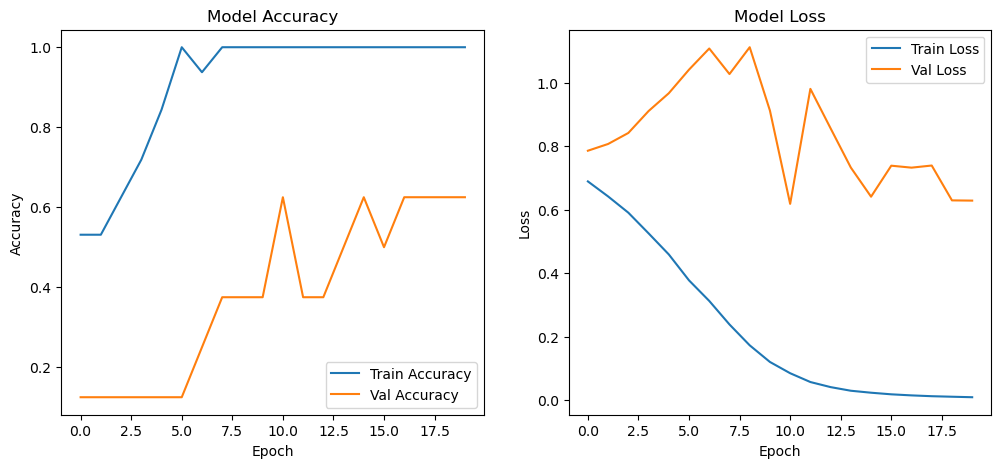

In [21]:
import matplotlib.pyplot as plt

# Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


## 📌 7. Evaluate Model
We test the model on unseen data.


In [25]:
# 7️⃣ Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {accuracy:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7000 - loss: 0.8036

✅ Test Accuracy: 0.70


## 📌 8. Make Predictions
Show predicted labels alongside actual text and labels.

### 🤔 Why model.predict(X_test) > 0.5?

The ANN outputs probabilities because the last layer uses a **Sigmoid activation**:  
This gives values between **0 and 1**, showing the probability of class 1 (Terrorism).  
Example:
- `0.48 → 48% chance Terrorism`
- `0.56 → 56% chance Terrorism`

---

### 🎯 Why threshold 0.5?
We use `> 0.5` to convert probabilities into class labels:
- Probability > 0.5 → Predict **Terrorism (1)**
- Probability ≤ 0.5 → Predict **Non-Terrorism (0)**

This is the **default threshold**.

---

### 📌 Can we change it?
✅ Yes! Adjust threshold based on needs:  
| Threshold | Effect                                     |
|-----------|---------------------------------------------|
| Lower (e.g., 0.3) | More sensitive (higher recall)      |
| Higher (e.g., 0.7) | More conservative (higher precision)|

Example:
```python
threshold = 0.3
y_pred = (model.predict(X_test) > threshold).astype(int)




In [28]:
pred = model.predict(X_test)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


array([[0.48642275],
       [0.04450523],
       [0.97917753],
       [0.09823355],
       [0.96993893],
       [0.7086264 ],
       [0.9259237 ],
       [0.8704974 ],
       [0.9685468 ],
       [0.69799745]], dtype=float32)

In [30]:
# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()

# Map encoded labels back to original
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(y_pred)

# Get sequences and padded sequences for test set
test_sequences = tokenizer.texts_to_sequences(text_test)
test_padded_sequences = pad_sequences(test_sequences, maxlen=max_length, padding='post')

# Create DataFrame with all details
results_df = pd.DataFrame({
    "Text": text_test.values,
    "Tokenized Sequence": test_sequences,
    "Padded Sequence": list(test_padded_sequences),
    "Actual Label": y_test_labels,
    "Predicted Label": y_pred_labels
}).reset_index(drop=True)

print("\n📌 Results (Text | Tokenized Sequence | Padded Sequence | Actual | Predicted):")
results_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

📌 Results (Text | Tokenized Sequence | Padded Sequence | Actual | Predicted):


,Text,Tokenized Sequence,Padded Sequence,Actual Label,Predicted Label
0,Healthcare workers vaccinated rural population,"[88, 89, 90, 33, 91]","[88, 89, 90, 33, 91, 0, 0, 0]",Non-Terrorism,Non-Terrorism
1,Cultural exchange program launched,"[187, 188, 189, 190]","[187, 188, 189, 190, 0, 0, 0, 0]",Non-Terrorism,Non-Terrorism
2,IED blast injures two soldiers on patrol,"[159, 15, 160, 161, 162, 14, 163]","[159, 15, 160, 161, 162, 14, 163, 0]",Terrorism,Terrorism
3,Job fair provides employment opportunities,"[208, 42, 209, 210, 211]","[208, 42, 209, 210, 211, 0, 0, 0]",Non-Terrorism,Non-Terrorism
4,Local community plants trees in public park,"[103, 104, 105, 106, 2, 107, 108]","[103, 104, 105, 106, 2, 107, 108, 0]",Non-Terrorism,Terrorism
5,Security alert issued after intelligence reports,"[7, 220, 39, 43, 38, 221]","[7, 220, 39, 43, 38, 221, 0, 0]",Terrorism,Terrorism
6,Rocket fired at military base from unknown location,"[142, 143, 13, 22, 144, 145, 146, 147]","[142, 143, 13, 22, 144, 145, 146, 147]",Terrorism,Terrorism
7,Blood donation camp organized by students,"[138, 139, 140, 141, 5, 29]","[138, 139, 140, 141, 5, 29, 0, 0]",Non-Terrorism,Terrorism
8,Security forces raid terrorist safe house,"[7, 12, 166, 9, 167, 168]","[7, 12, 166, 9, 167, 168, 0, 0]",Terrorism,Terrorism
9,Economic growth hits record high this quarter,"[113, 114, 115, 116, 117, 21, 118]","[113, 114, 115, 116, 117, 21, 118, 0]",Non-Terrorism,Terrorism


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
# 📊 Classification Report
print("\n📑 Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


📑 Classification Report:
               precision    recall  f1-score   support

Non-Terrorism       1.00      0.50      0.67         6
    Terrorism       0.57      1.00      0.73         4

     accuracy                           0.70        10
    macro avg       0.79      0.75      0.70        10
 weighted avg       0.83      0.70      0.69        10




 Confusion Matrix:


C:\Users\waqar\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


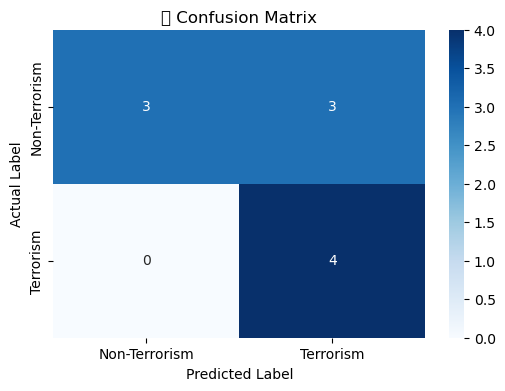

In [34]:
import seaborn as sns
# 📊 Confusion Matrix
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

# 🎨 Confusion Matrix (Visual)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("🔵 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()